# Baseline Model

## Library Imports

In [51]:
# Library Imports
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
# import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Constants and Defines
INPUT_FILE      = "dataset.csv"
CHECKPOINT_DIR  = "checkpoints"
FINAL_MODEL     = "model_final.pth"

INPUTS   = ["gain_max_dB", "pm", "gbw"]
OUTPUTS  = ["w1", "w3"]

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
TEST_RATIO = 0.10

EPOCHS        = 300
BATCH_SIZE    = 32
LR            = 1e-3
CHECKPOINT_EVERY = 5
ACC_THRESHOLD = 0.25

SEED = 42

## Loading Dataset

In [52]:
# Prepare Checkpoint Directory and Load Data
torch.manual_seed(SEED)
np.random.seed(SEED)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_FILE).sample(frac=1, random_state=SEED).reset_index(drop=True)

X = df[INPUTS].values.astype(np.float32)
y = df[OUTPUTS].values.astype(np.float32)

n = len(df)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

# create data splits across ratios
X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]


X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_val   = X_scaler.transform(X_val)
X_test  = X_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)

print(f"Dataset split - train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

def to_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader = to_loader(X_val, y_val)
test_loader = to_loader(X_test, y_test)

Dataset split - train: 3080, val: 880, test: 440


## Model Class Definition

In [53]:
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # linear layers
        self.linear = nn.Linear(3, 2)

        # activation
        self.relu = nn.LeakyReLU()
    
    def forward(self, x):
        x = self.linear(x)

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Training/Evaluation Function Definitions
### Measuring Accuracy
[need to explain how we're measuring accuracy here]

In [54]:
def evaluate(model, dataloader, criterion, device, y_scaler, threshold):
    model.eval()

    total_loss = 0
    correct = 0

    with torch.no_grad():
        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            predictions = model(X)

            loss = criterion(predictions, y)

            total_loss += loss.item() * X.size(0)

            # Inverse transform predictions and labels
            pred_orig = y_scaler.inverse_transform(predictions.cpu().numpy())
            y_orig = y_scaler.inverse_transform(y.cpu().numpy())

            # Compute relative errors
            rel_errors = np.abs((pred_orig - y_orig) / y_orig)

            # For each sample, if max relative error <= threshold, count as correct
            correct += np.sum(np.max(rel_errors, axis=1) <= threshold)

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = correct / len(dataloader.dataset) * 100
    return avg_loss, accuracy

def train(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    for X, y in dataloader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        predictions = model(X)

        loss = criterion(predictions, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

In [55]:
# create model and associated objects
model = BaselineModel().to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

# intialize lists to store metrics
train_acc_history = []
val_acc_history = []
train_mse_history = []
val_mse_history = []



for epoch in range(EPOCHS):

    train_loss = train(model, train_loader, optim, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, y_scaler, ACC_THRESHOLD)
    train_loss, train_acc = evaluate(model, train_loader, criterion, device, y_scaler, ACC_THRESHOLD)

    # Append to histories
    train_mse_history.append(train_loss)
    val_mse_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | "
        f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%"
    )


Epoch 1/300 | Train Loss: 0.869785 | Val Loss: 0.855187 | Train Acc: 9.38% | Val Acc: 9.43%
Epoch 2/300 | Train Loss: 0.698820 | Val Loss: 0.689098 | Train Acc: 12.14% | Val Acc: 10.91%
Epoch 3/300 | Train Loss: 0.573779 | Val Loss: 0.567613 | Train Acc: 15.03% | Val Acc: 13.64%
Epoch 4/300 | Train Loss: 0.481362 | Val Loss: 0.478015 | Train Acc: 17.47% | Val Acc: 16.14%
Epoch 5/300 | Train Loss: 0.414110 | Val Loss: 0.413208 | Train Acc: 20.49% | Val Acc: 18.75%
Epoch 6/300 | Train Loss: 0.366580 | Val Loss: 0.367510 | Train Acc: 23.51% | Val Acc: 22.05%
Epoch 7/300 | Train Loss: 0.333087 | Val Loss: 0.335526 | Train Acc: 26.95% | Val Acc: 24.89%
Epoch 8/300 | Train Loss: 0.310265 | Val Loss: 0.313754 | Train Acc: 28.99% | Val Acc: 27.73%
Epoch 9/300 | Train Loss: 0.294920 | Val Loss: 0.299376 | Train Acc: 32.37% | Val Acc: 30.80%
Epoch 10/300 | Train Loss: 0.284555 | Val Loss: 0.289818 | Train Acc: 32.60% | Val Acc: 31.59%
Epoch 11/300 | Train Loss: 0.277815 | Val Loss: 0.283698 | Tr

<Figure size 1000x500 with 0 Axes>

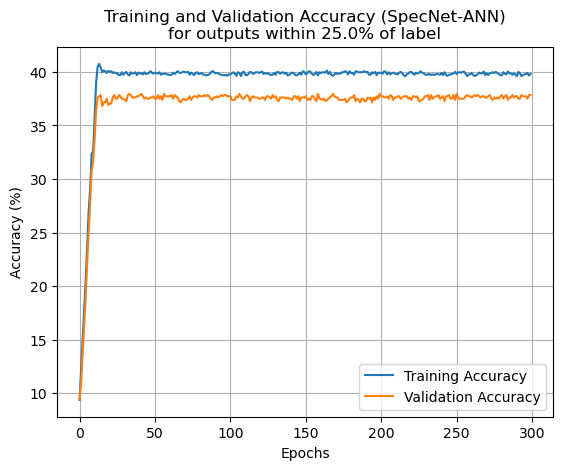

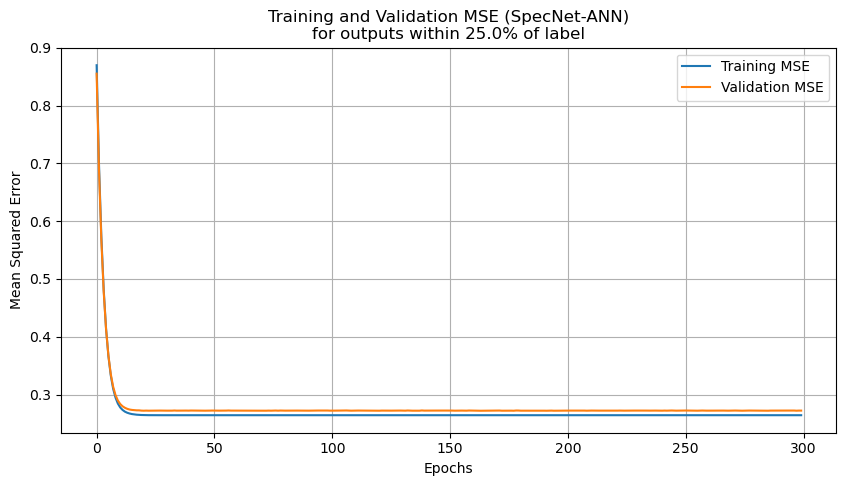

In [56]:
# plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.figure()
plt.plot(train_acc_history, label="Training Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy (SpecNet-ANN)\n"
         f"for outputs within {ACC_THRESHOLD*100}% of label")
plt.legend()
plt.grid(True)
# plt.show()
plt.savefig(f"accuracy_curve_{ACC_THRESHOLD}.png", dpi=300, bbox_inches="tight")

# plot training and validation MSE
plt.figure(figsize=(10, 5))
plt.plot(train_mse_history, label="Training MSE")
plt.plot(val_mse_history, label="Validation MSE")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Training and Validation MSE (SpecNet-ANN)\n"
         f"for outputs within {ACC_THRESHOLD*100}% of label")
plt.legend()
plt.grid(True)
# plt.show()
plt.savefig(f"mse_curve_{ACC_THRESHOLD}.png", dpi=300, bbox_inches="tight")

## Model on the Test Dataset

In [57]:
test_mse, test_acc = evaluate(model, test_loader, criterion, device, y_scaler, ACC_THRESHOLD)
print(f"Test Acc: {test_acc:.2f}% | Test MSE: {test_mse:.6f}")

Test Acc: 38.41% | Test MSE: 0.250771


## Miscellaneous Plots

<Figure size 1000x500 with 0 Axes>

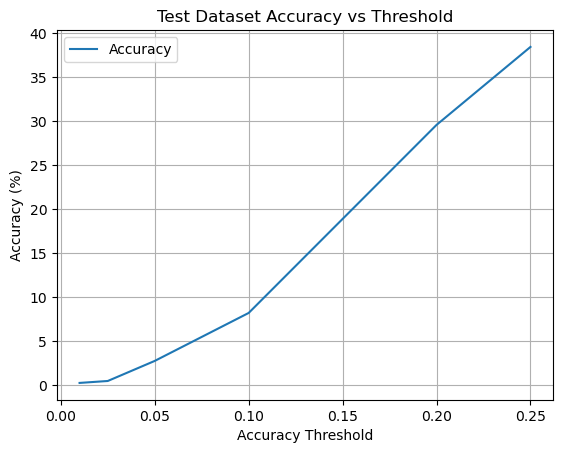

In [59]:
my_list_x = [0.01, 0.025, 0.05, 0.1, 0.2, 0.25]
my_list_y = [0.23, 0.45, 2.73, 8.18, 29.55, 38.41]

plt.figure(figsize=(10, 5))
plt.figure()
plt.plot(my_list_x, my_list_y, label="Accuracy")
plt.xlabel("Accuracy Threshold")
plt.ylabel("Accuracy (%)")
plt.title("Test Dataset Accuracy vs Threshold")
plt.legend()
plt.grid(True)
plt.savefig(f"threshold.png", dpi=300, bbox_inches="tight")